<a href="https://colab.research.google.com/github/uditigupta293-byte/-Real-Estate-Market-Analysis/blob/main/Real_Estate_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
from zipfile import ZipFile

zip_path = '/content/drive/MyDrive/kaggledatasets/archive (1).zip'

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/kaggledatasets/extracted')

In [8]:
df = pd.read_csv(
    '/content/drive/MyDrive/kaggledatasets/extracted/data of gurugram real Estate.csv'
)

df.head()

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Socity,Company Name,Flat Type
0,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000.0,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3.0,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000.0,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4.0,Outside Socity,Outside,Plot
4,24000000.0,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3.0,Anant Raj Estate Plots,Anant,Floor


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          19515 non-null  object 
 1   Status         19515 non-null  object 
 2   Area           19515 non-null  int64  
 3   Rate per sqft  19515 non-null  object 
 4   Property Type  19515 non-null  object 
 5   Locality       19515 non-null  object 
 6   Builder Name   19515 non-null  object 
 7   RERA Approval  19515 non-null  object 
 8   BHK_Count      19515 non-null  float64
 9   Socity         19515 non-null  object 
 10  Company Name   19515 non-null  object 
 11  Flat Type      19515 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 1.8+ MB


In [12]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [14]:
df["price"] = df["price"].astype(str).str.replace(",", "").astype(float).astype(int)

df["area"] = df["area"].astype(str).str.replace(",", "").astype(float).astype(int)

df["rate_per_sqft"] = df["rate_per_sqft"].astype(str).str.replace(",", "").astype(float).astype(int)

In [15]:
df["status"] = df["status"].str.strip().str.lower()
df["rera_approval"] = df["rera_approval"].str.strip().str.lower()
df["flat_type"] = df["flat_type"].str.strip().str.lower()

In [16]:
df = df.drop_duplicates()

Question 1: Which is the costliest flat?

In [17]:
df.loc[df["price"].idxmax()] #.loc[] is used to fetch the complete row corresponding to the maximum price.

,2839
price,1226300000
status,ready to move
area,16500
rate_per_sqft,74323
property_type,6 BHK Apartment in DLF Camellias
locality,Sector 42
builder_name,Provident Capital
rera_approval,not approved by rera
bhk_count,6.0
socity,DLF Camellias


Question 2: Which locality has the highest average price?

In [18]:
df.groupby("locality")["price"].mean().sort_values(ascending=False) #groupby("locality")->This groups all properties belonging to the same locality together.

,price
locality,
Baliawas,5.833333e+08
Sector 42,5.023612e+08
Beverly Park,1.953667e+08
Aralias Drive,1.636583e+08
Golf Course Road,1.475139e+08
...,...
Sohna Rewari Road,6.200000e+05
SULTANPUR BIRD CENTU,6.000000e+05
Sultanpur,4.875000e+05


Question 3: Which locality has the highest rate per square foot?

In [29]:
df.groupby("locality")["rate_per_sqft"].median().sort_values(ascending=False)

,rate_per_sqft
locality,
Sector 42,56697.5
Sector 114,33347.0
Sector 80,31139.0
Sector 54,27722.0
Beverly Park,26465.0
...,...
Sohna Palwal Road,688.0
Sohna Rewari Road,688.0
Sector 1 Sohna,577.0


Question 4: Ready-to-move vs Under-construction pricing

In [20]:
df.groupby("status")["price"].median()

,price
status,
new,13450000.0
ready to move,26000000.0
resale,36500000.0
under construction,28600000.0


Question 5: Does RERA approval affect pricing?

In [21]:
df.groupby("rera_approval")["price"].median()

,price
rera_approval,
approved by rera,27100000.0
not approved by rera,25800000.0


Question 6: How does area impact price?

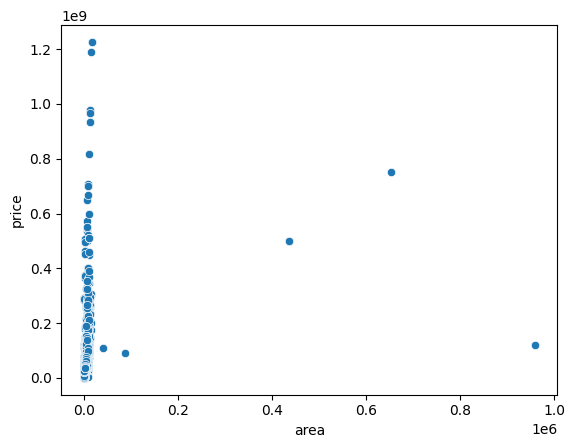

In [22]:
sns.scatterplot(x="area", y="price", data=df)
plt.show()

Which BHK configuration is most expensive?

In [30]:
df.groupby("bhk_count")["price"].median()

,price
bhk_count,
0.0,14100000.0
1.0,3000000.0
2.0,10600000.0
3.0,25000000.0
4.0,44900000.0
5.0,94500000.0
6.0,95000000.0
7.0,110000000.0
8.0,45500000.0


Question 8: Which property type is the costliest?

In [34]:
df.groupby("flat_type")["price"].median().sort_values(ascending=False)

,price
flat_type,
house,101000000.0
penthouse,95000000.0
villa,82600000.0
apartment,28000000.0
floor,23000000.0
plot,16650000.0


Question 9: Do certain builders price higher?

In [35]:
df.groupby("company_name")["price"].median().sort_values(ascending=False)

,price
company_name,
Baliawas,750000000.0
Camelliaass,460000000.0
Cameliaas,360000000.0
Magnoliaaa,160000000.0
Magnoliaass,160000000.0
...,...
JMD,1300000.0
OM,688500.0
SOHNA,650000.0


Question 10: Are larger homes more expensive per sqft?

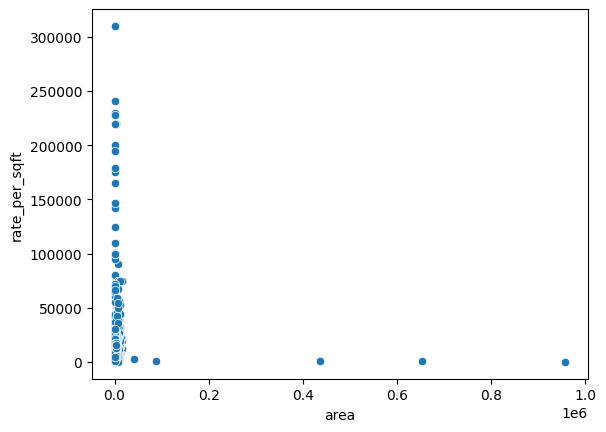

In [26]:
sns.scatterplot(x="area", y="rate_per_sqft", data=df)
plt.show()

From the analysis, we can conclude:

1) Premium localities consistently show higher prices and rate per sqft

2) Ready-to-move and RERA-approved properties tend to command higher prices

3) Builder reputation significantly impacts property pricing

4) Larger homes are not always more expensive per sqft

5) Apartments generally have higher rate per sqft than plots and floors